In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.animation as animation
import datetime
import seaborn as sns
import missingno as msno
import firebase_admin
import pygwalker as pyg
from firebase_admin import credentials, db
from datetime import datetime  # Untuk konversi timestamp ke human-readable
sns.set_theme(style="whitegrid")
%matplotlib inline 

In [2]:
# Konfigurasi database sumber
source_cred = credentials.Certificate("D:/staklimjerukagung-firebase-adminsdk-kcfma-e091165a9b.json")
firebase_admin.initialize_app(source_cred, {
    'databaseURL': 'https://staklimjerukagung-default-rtdb.asia-southeast1.firebasedatabase.app/'
})

In [3]:
# Input readable date
start_readable_date = "01-01-2026 00:00:00"  # Format: DD-MM-YYYY HH:MM:SS
end_readable_date = "31-12-2026 23:59:59"  # Format: DD-MM-YYYY HH:MM:SS

# Convert readable date to Unix timestamp
start_timestamp = int(datetime.strptime(start_readable_date, "%d-%m-%Y %H:%M:%S").timestamp())
print(start_timestamp) # Convert to string and print
end_timestamp = int(datetime.strptime(end_readable_date, "%d-%m-%Y %H:%M:%S").timestamp())
print(end_timestamp) # Convert to string and print


1767200400
1798736399


In [4]:
# Refer ke path data
ref_data1 = db.reference('/auto_weather_stat/id-03/data')
ref_data2 = db.reference('/auto_weather_stat/id-05/data')

# Ambil data yang key-nya berada dalam rentang waktu yang ditentukan
query_data1 = ref_data1.order_by_key().start_at(str(start_timestamp)).end_at(str(end_timestamp))
query_data2 = ref_data2.order_by_key().start_at(str(start_timestamp)).end_at(str(end_timestamp))

# Ambil hasil
results_data1 = query_data1.get()
results_data2 = query_data2.get()

In [5]:
# Mengubah data menjadi DataFrame pandas untuk data pertama
if results_data1:
    cuaca1 = pd.DataFrame.from_dict(results_data1, orient='index')
    
    # Jika 'timestamp' sudah ada, jangan pindahkan indeks ke kolom
    if 'timestamp' not in cuaca1.columns:
        cuaca1.index.name = 'timestamp'  # Mengatur nama indeks
        cuaca1.reset_index(inplace=True)  # Memindahkan indeks menjadi kolom biasa
    
    print("Data dari sumber pertama:")
    print(cuaca1.head())  # Menampilkan data untuk verifikasi
else:
    print("Tidak ada data dari sumber pertama")

# Mengubah data menjadi DataFrame pandas untuk data kedua
if results_data2:
    cuaca2 = pd.DataFrame.from_dict(results_data2, orient='index')
    
    # Jika 'timestamp' sudah ada, jangan pindahkan indeks ke kolom
    if 'timestamp' not in cuaca2.columns:
        cuaca2.index.name = 'timestamp'  # Mengatur nama indeks
        cuaca2.reset_index(inplace=True)  # Memindahkan indeks menjadi kolom biasa
    
    print("Data dari sumber kedua:")
    print(cuaca2.head())  # Menampilkan data untuk verifikasi
else:
    print("Tidak ada data dari sumber kedua")

Data dari sumber pertama:
                 dew  humidity  pressure  temperature   timestamp  volt  \
1767200430  25.50131     99.18   1007.77        25.64  1767200430  4.09   
1767200490  25.48793     99.16   1007.75        25.63  1767200490  4.09   
1767200550  25.51130     99.18   1007.73        25.65  1767200550  4.10   
1767200610  25.49132     99.18   1007.74        25.63  1767200610  4.09   
1767200670  25.47134     99.18   1007.68        25.61  1767200670  4.09   

            rainfall  rainrate  lux  soil_temp  tips  
1767200430       NaN       NaN  NaN        NaN   NaN  
1767200490       NaN       NaN  NaN        NaN   NaN  
1767200550       NaN       NaN  NaN        NaN   NaN  
1767200610       NaN       NaN  NaN        NaN   NaN  
1767200670       NaN       NaN  NaN        NaN   NaN  
Data dari sumber kedua:
                 dew  humidity  pressure  rainfall  rainrate  temperature  \
1767200459  25.69148  98.01503   1007.95    6.1085       0.0     26.03075   
1767200519  25.

In [6]:
cuaca1.tail(10)

,dew,humidity,pressure,temperature,timestamp,volt,rainfall,rainrate,lux,soil_temp,tips
1780763924,23.21092,93.60,1012.19,24.31,1780763924,4.07,0.0,0.0,NaN,NaN,NaN
1780763984,23.16949,93.59,1012.17,24.27,1780763984,4.07,0.0,0.0,NaN,NaN,NaN
1780763987,23.16949,93.59,1012.17,24.27,1780763987,4.07,0.0,0.0,NaN,NaN,NaN
1780764045,23.17302,93.61,1012.16,24.27,1780764045,4.07,0.0,0.0,NaN,NaN,NaN
1780764105,23.13620,93.57,1012.19,24.24,1780764105,4.07,0.0,0.0,NaN,NaN,NaN
1780764165,23.15672,93.63,1012.16,24.25,1780764165,4.07,0.0,0.0,NaN,NaN,NaN
1780764166,23.15672,93.63,1012.16,24.25,1780764166,4.07,0.0,0.0,NaN,NaN,NaN
1780764225,23.16202,93.66,1012.17,24.25,1780764225,4.08,0.0,0.0,NaN,NaN,NaN
1780764285,23.12873,93.64,1012.16,24.22,1780764285,4.07,0.0,0.0,NaN,NaN,NaN
1780764345,23.11949,93.70,1012.13,24.20,1780764345,4.07,0.0,0.0,NaN,NaN,NaN


In [7]:
cuaca1['timestamp']= cuaca1['timestamp'].astype(int)
cuaca2['timestamp']= cuaca2['timestamp'].astype(int)
cuaca1.tail(10)

,dew,humidity,pressure,temperature,timestamp,volt,rainfall,rainrate,lux,soil_temp,tips
1780763924,23.21092,93.60,1012.19,24.31,1780763924,4.07,0.0,0.0,NaN,NaN,NaN
1780763984,23.16949,93.59,1012.17,24.27,1780763984,4.07,0.0,0.0,NaN,NaN,NaN
1780763987,23.16949,93.59,1012.17,24.27,1780763987,4.07,0.0,0.0,NaN,NaN,NaN
1780764045,23.17302,93.61,1012.16,24.27,1780764045,4.07,0.0,0.0,NaN,NaN,NaN
1780764105,23.13620,93.57,1012.19,24.24,1780764105,4.07,0.0,0.0,NaN,NaN,NaN
1780764165,23.15672,93.63,1012.16,24.25,1780764165,4.07,0.0,0.0,NaN,NaN,NaN
1780764166,23.15672,93.63,1012.16,24.25,1780764166,4.07,0.0,0.0,NaN,NaN,NaN
1780764225,23.16202,93.66,1012.17,24.25,1780764225,4.08,0.0,0.0,NaN,NaN,NaN
1780764285,23.12873,93.64,1012.16,24.22,1780764285,4.07,0.0,0.0,NaN,NaN,NaN
1780764345,23.11949,93.70,1012.13,24.20,1780764345,4.07,0.0,0.0,NaN,NaN,NaN


In [8]:
# Konversi timestamp ke datetime dalam format UTC
cuaca1['timestamp'] = pd.to_datetime(cuaca1['timestamp'], unit='s', utc=True)
cuaca2['timestamp'] = pd.to_datetime(cuaca2['timestamp'], unit='s', utc=True)

# Mengonversi ke zona waktu WIB (Asia/Jakarta)
cuaca1['timestamp'] = cuaca1['timestamp'].dt.tz_convert('Asia/Jakarta')
cuaca2['timestamp'] = cuaca2['timestamp'].dt.tz_convert('Asia/Jakarta')

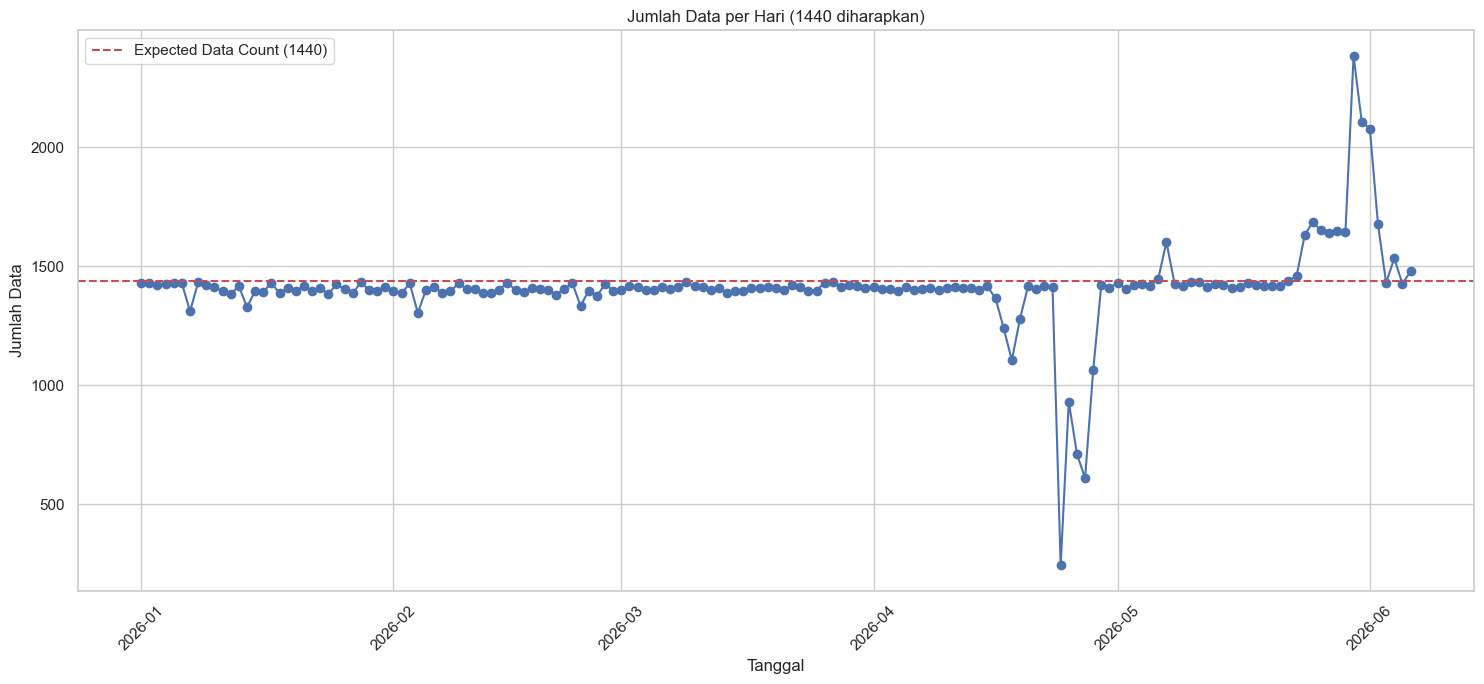

Hari dengan jumlah data yang kurang dari 1440:
           date  count
0    2026-01-01   1428
1    2026-01-02   1430
2    2026-01-03   1422
3    2026-01-04   1427
4    2026-01-05   1429
..          ...    ...
152  2026-06-02   1676
153  2026-06-03   1430
154  2026-06-04   1534
155  2026-06-05   1426
156  2026-06-06   1478

[157 rows x 2 columns]


In [9]:
# Mengelompokkan data berdasarkan hari
cuaca1['date'] = cuaca1['timestamp'].dt.date
data_per_day = cuaca1.groupby('date').size().reset_index(name='count')

# Visualisasi jumlah data per hari
plt.figure(figsize=(15, 7))
plt.plot(data_per_day['date'], data_per_day['count'], marker='o', linestyle='-')
plt.axhline(y=1440, color='r', linestyle='--', label='Expected Data Count (1440)')
plt.xlabel('Tanggal')
plt.ylabel('Jumlah Data')
plt.title('Jumlah Data per Hari (1440 diharapkan)')
plt.xticks(rotation=45)
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# Menampilkan hari-hari yang tidak memenuhi 1440 data
days_with_missing_data = data_per_day[data_per_day['count'] != 1440]
print("Hari dengan jumlah data yang kurang dari 1440:")
print(days_with_missing_data)

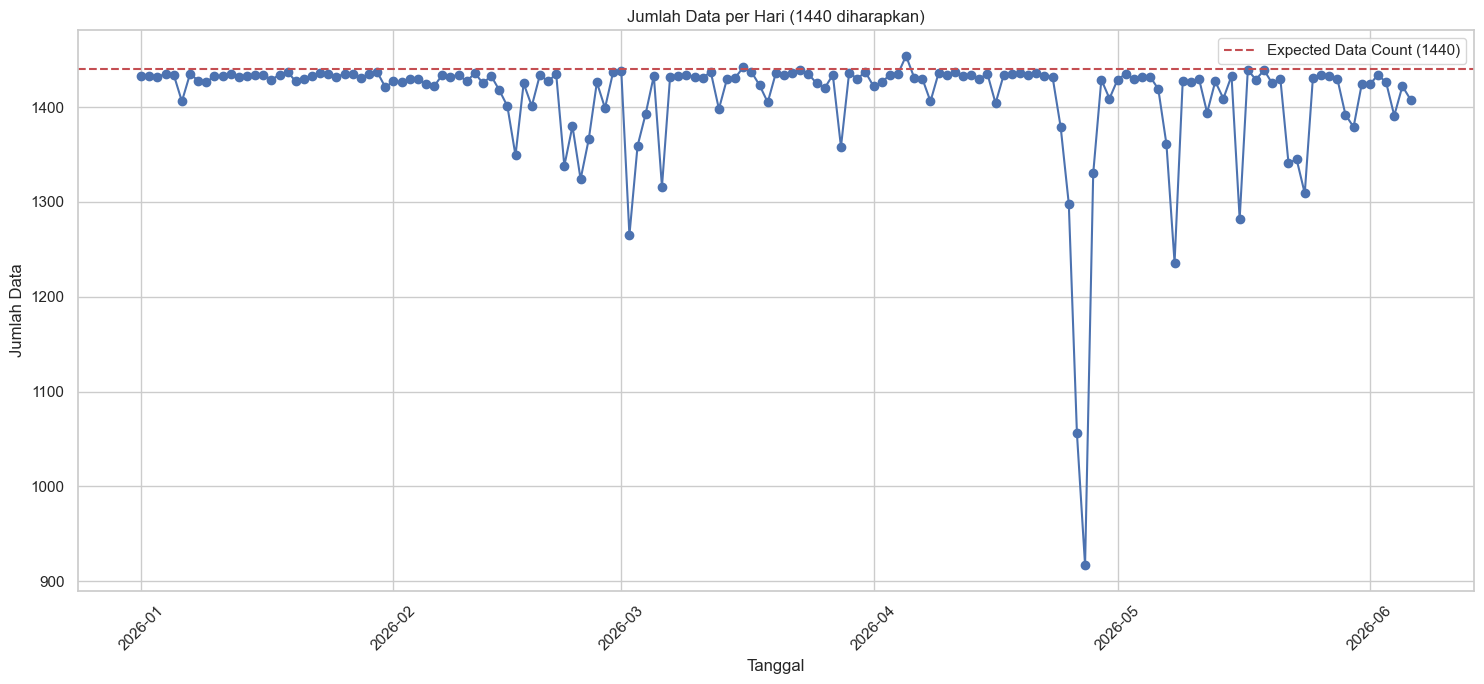

Hari dengan jumlah data yang kurang dari 1440:
           date  count
0    2026-01-01   1433
1    2026-01-02   1433
2    2026-01-03   1432
3    2026-01-04   1435
4    2026-01-05   1434
..          ...    ...
152  2026-06-02   1434
153  2026-06-03   1426
154  2026-06-04   1391
155  2026-06-05   1422
156  2026-06-06   1408

[157 rows x 2 columns]


In [10]:
# Mengelompokkan data berdasarkan hari
cuaca2['date'] = cuaca2['timestamp'].dt.date
data_per_day = cuaca2.groupby('date').size().reset_index(name='count')

# Visualisasi jumlah data per hari
plt.figure(figsize=(15, 7))
plt.plot(data_per_day['date'], data_per_day['count'], marker='o', linestyle='-')
plt.axhline(y=1440, color='r', linestyle='--', label='Expected Data Count (1440)')
plt.xlabel('Tanggal')
plt.ylabel('Jumlah Data')
plt.title('Jumlah Data per Hari (1440 diharapkan)')
plt.xticks(rotation=45)
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# Menampilkan hari-hari yang tidak memenuhi 1440 data
days_with_missing_data = data_per_day[data_per_day['count'] != 1440]
print("Hari dengan jumlah data yang kurang dari 1440:")
print(days_with_missing_data)

In [11]:
cuaca1.dtypes

dew                                 float64
humidity                            float64
pressure                            float64
temperature                         float64
timestamp      datetime64[ns, Asia/Jakarta]
volt                                float64
rainfall                            float64
rainrate                            float64
lux                                 float64
soil_temp                           float64
tips                                float64
date                                 object
dtype: object

In [12]:
cuaca2.dtypes

dew                                 float64
humidity                            float64
pressure                            float64
rainfall                            float64
rainrate                            float64
temperature                         float64
timestamp      datetime64[ns, Asia/Jakarta]
volt                                float64
tips                                float64
rain_rate                           float64
date                                 object
dtype: object

In [13]:
cuaca1.head(10)

,dew,humidity,pressure,temperature,timestamp,volt,rainfall,rainrate,lux,soil_temp,tips,date
1767200430,25.50131,99.18,1007.77,25.64,2026-01-01 00:00:30+07:00,4.09,NaN,NaN,NaN,NaN,NaN,2026-01-01
1767200490,25.48793,99.16,1007.75,25.63,2026-01-01 00:01:30+07:00,4.09,NaN,NaN,NaN,NaN,NaN,2026-01-01
1767200550,25.51130,99.18,1007.73,25.65,2026-01-01 00:02:30+07:00,4.10,NaN,NaN,NaN,NaN,NaN,2026-01-01
1767200610,25.49132,99.18,1007.74,25.63,2026-01-01 00:03:30+07:00,4.09,NaN,NaN,NaN,NaN,NaN,2026-01-01
1767200670,25.47134,99.18,1007.68,25.61,2026-01-01 00:04:30+07:00,4.09,NaN,NaN,NaN,NaN,NaN,2026-01-01
1767200730,25.50131,99.18,1007.66,25.64,2026-01-01 00:05:30+07:00,4.09,NaN,NaN,NaN,NaN,NaN,2026-01-01
1767200790,25.49132,99.18,1007.64,25.63,2026-01-01 00:06:30+07:00,4.09,NaN,NaN,NaN,NaN,NaN,2026-01-01
1767200850,25.49302,99.19,1007.61,25.63,2026-01-01 00:07:30+07:00,4.09,NaN,NaN,NaN,NaN,NaN,2026-01-01
1767200910,25.50131,99.18,1007.62,25.64,2026-01-01 00:08:30+07:00,4.09,NaN,NaN,NaN,NaN,NaN,2026-01-01
1767200970,25.46965,99.17,1007.58,25.61,2026-01-01 00:09:30+07:00,4.10,NaN,NaN,NaN,NaN,NaN,2026-01-01


In [14]:
datacuaca = cuaca1
datacuaca2 = cuaca2

Visualisasi missing values untuk datacuaca:


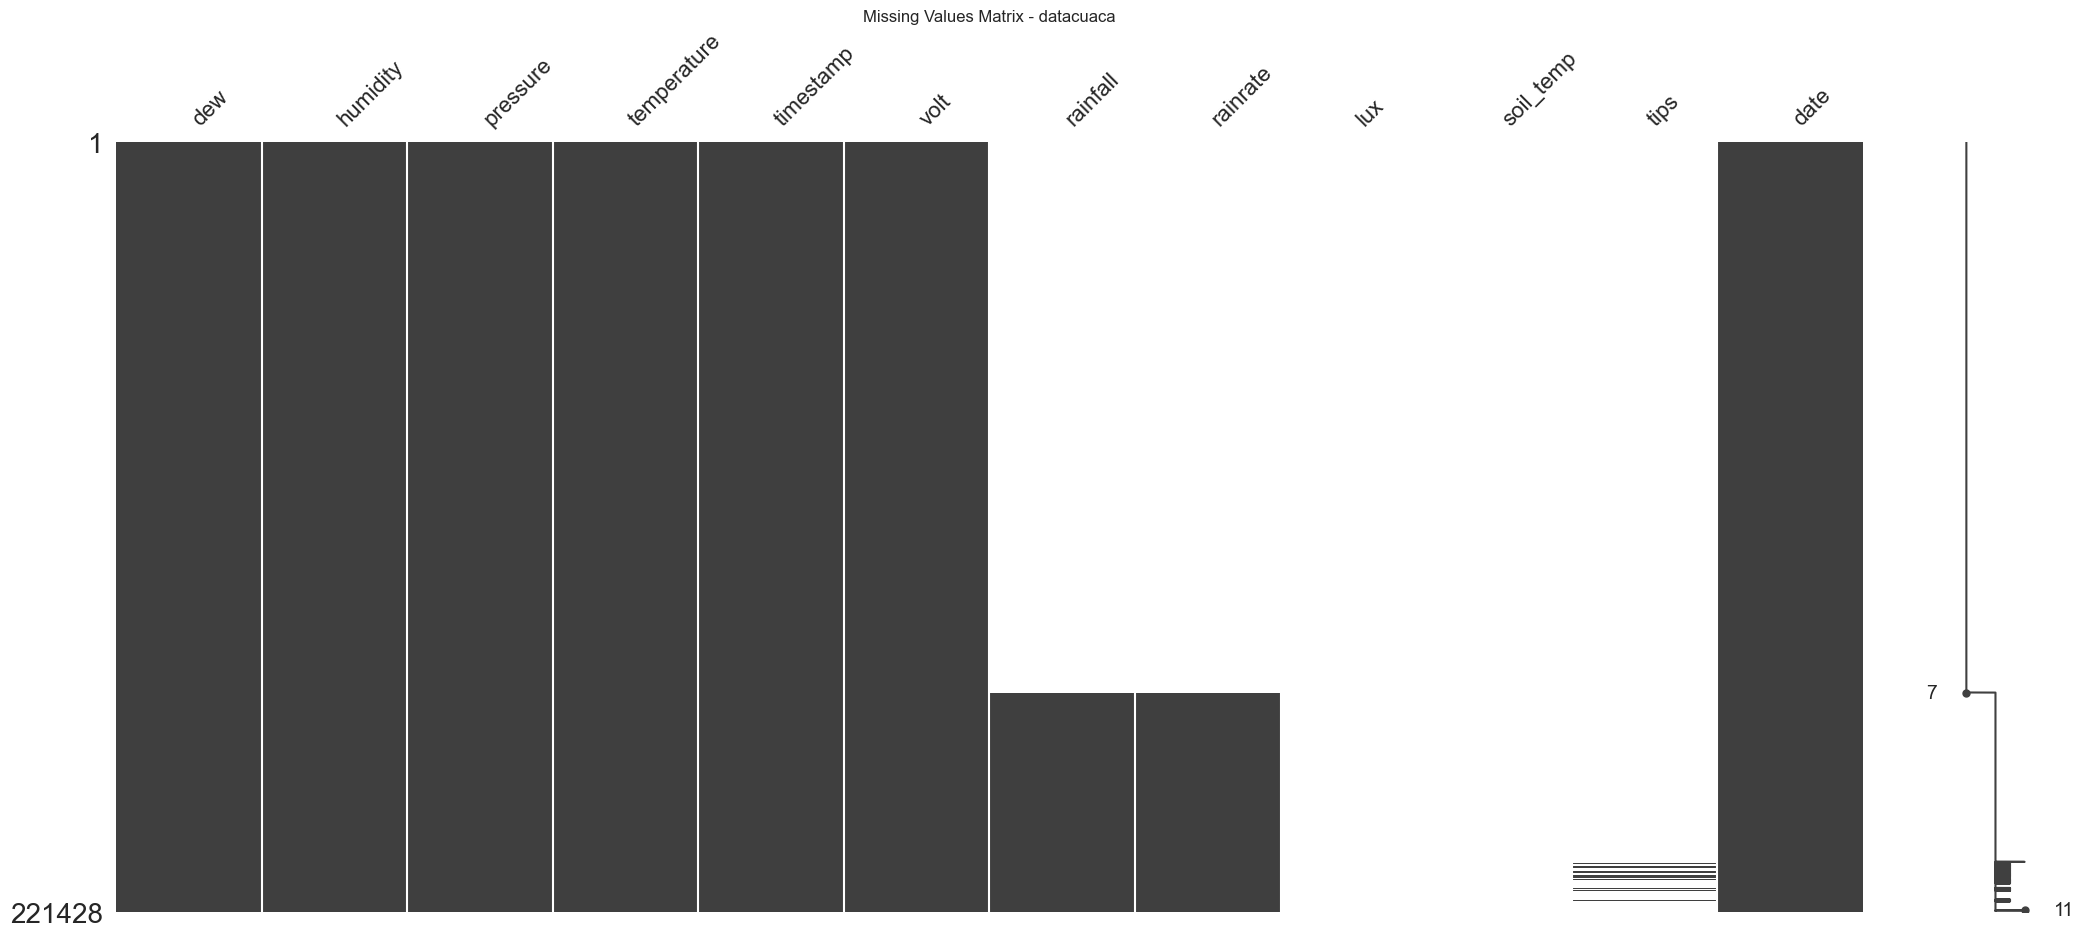

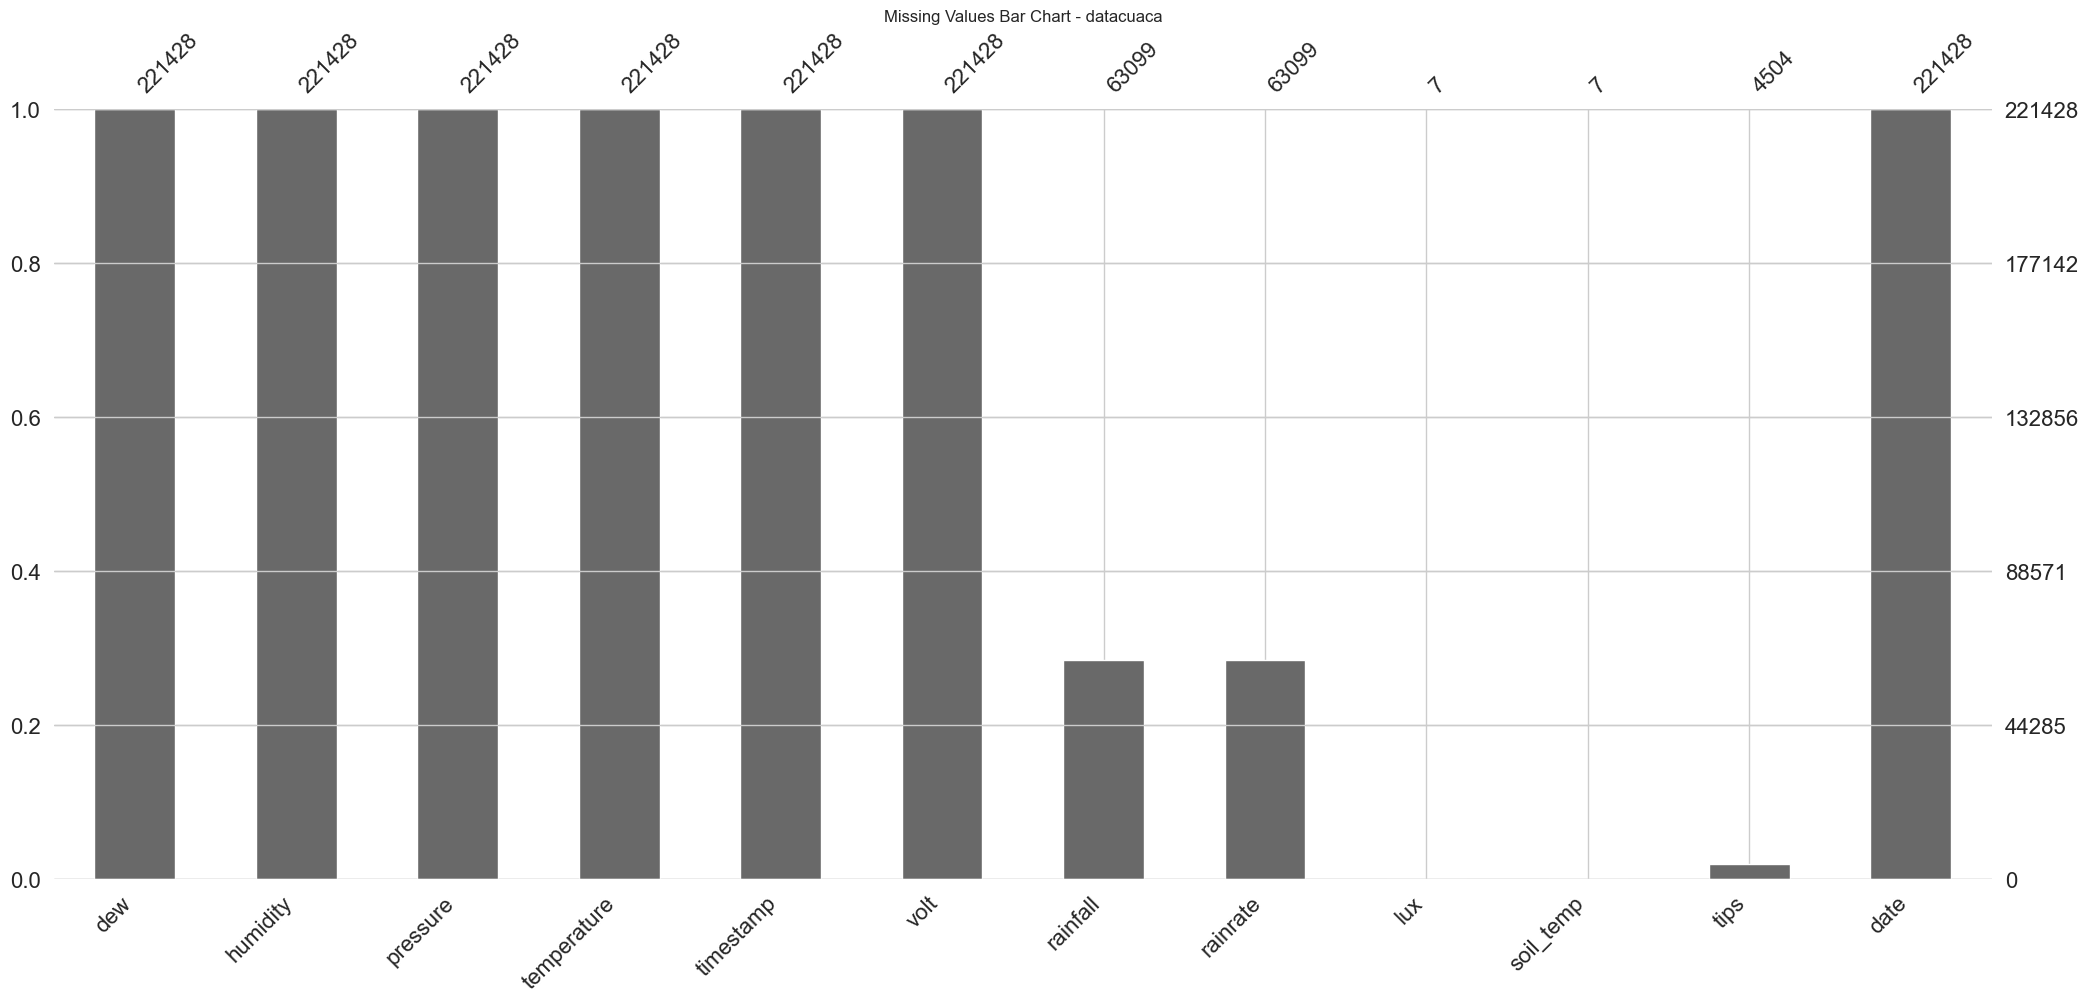

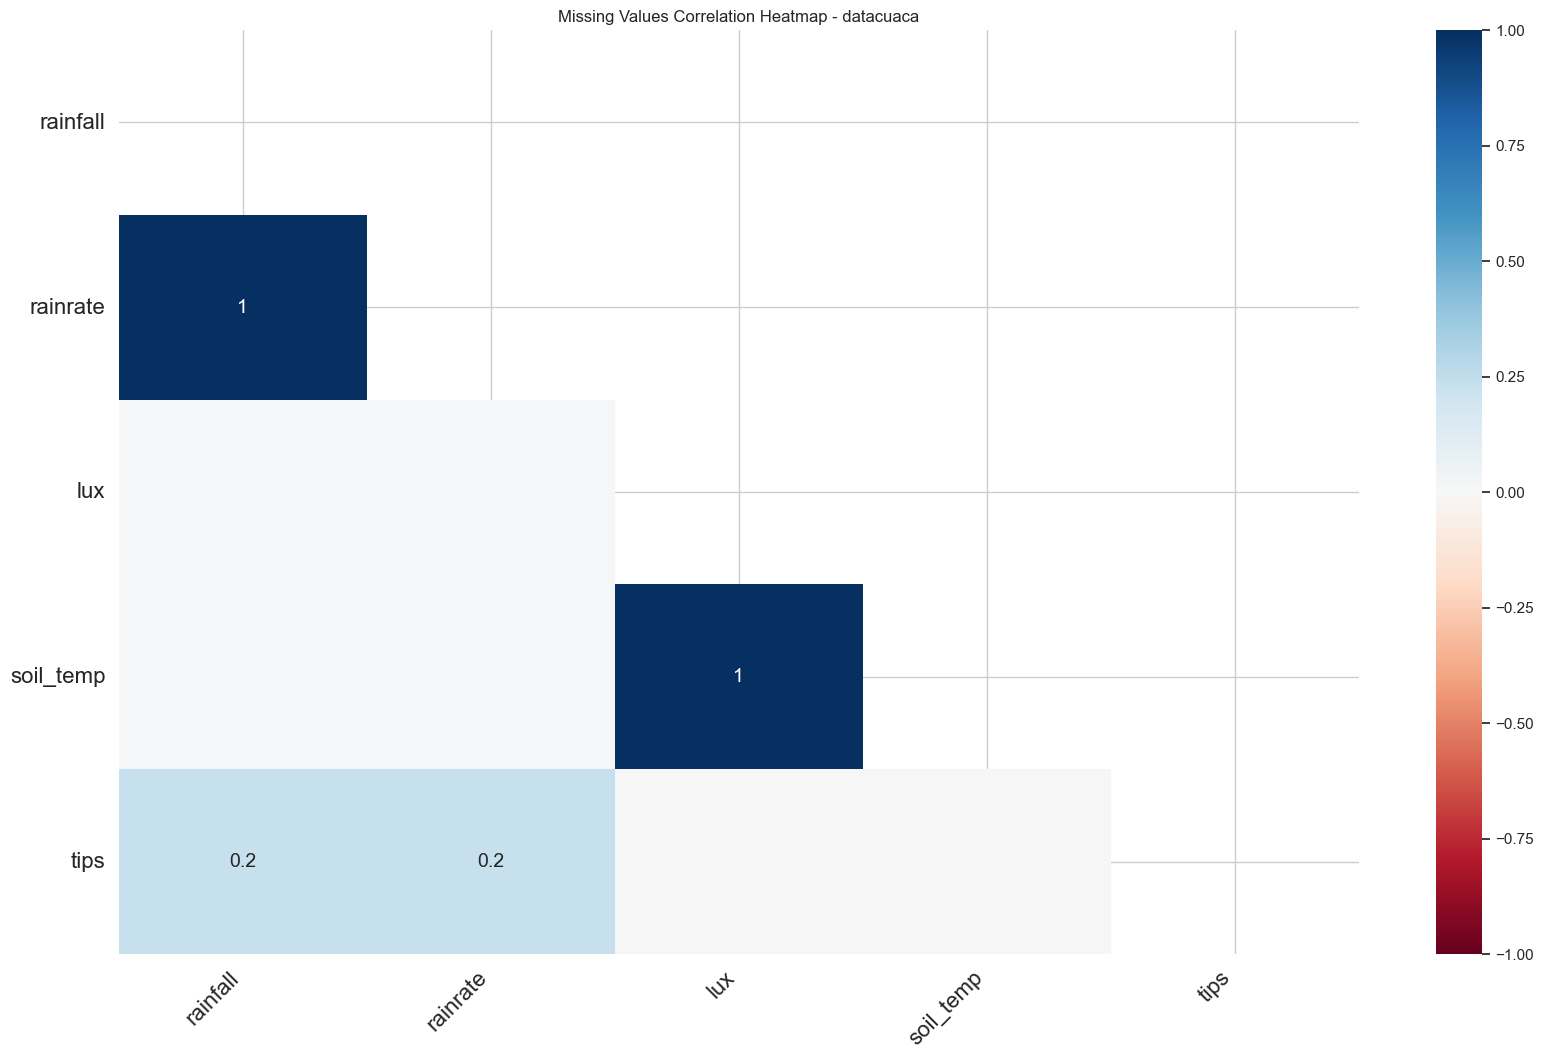

Visualisasi missing values untuk datacuaca2:


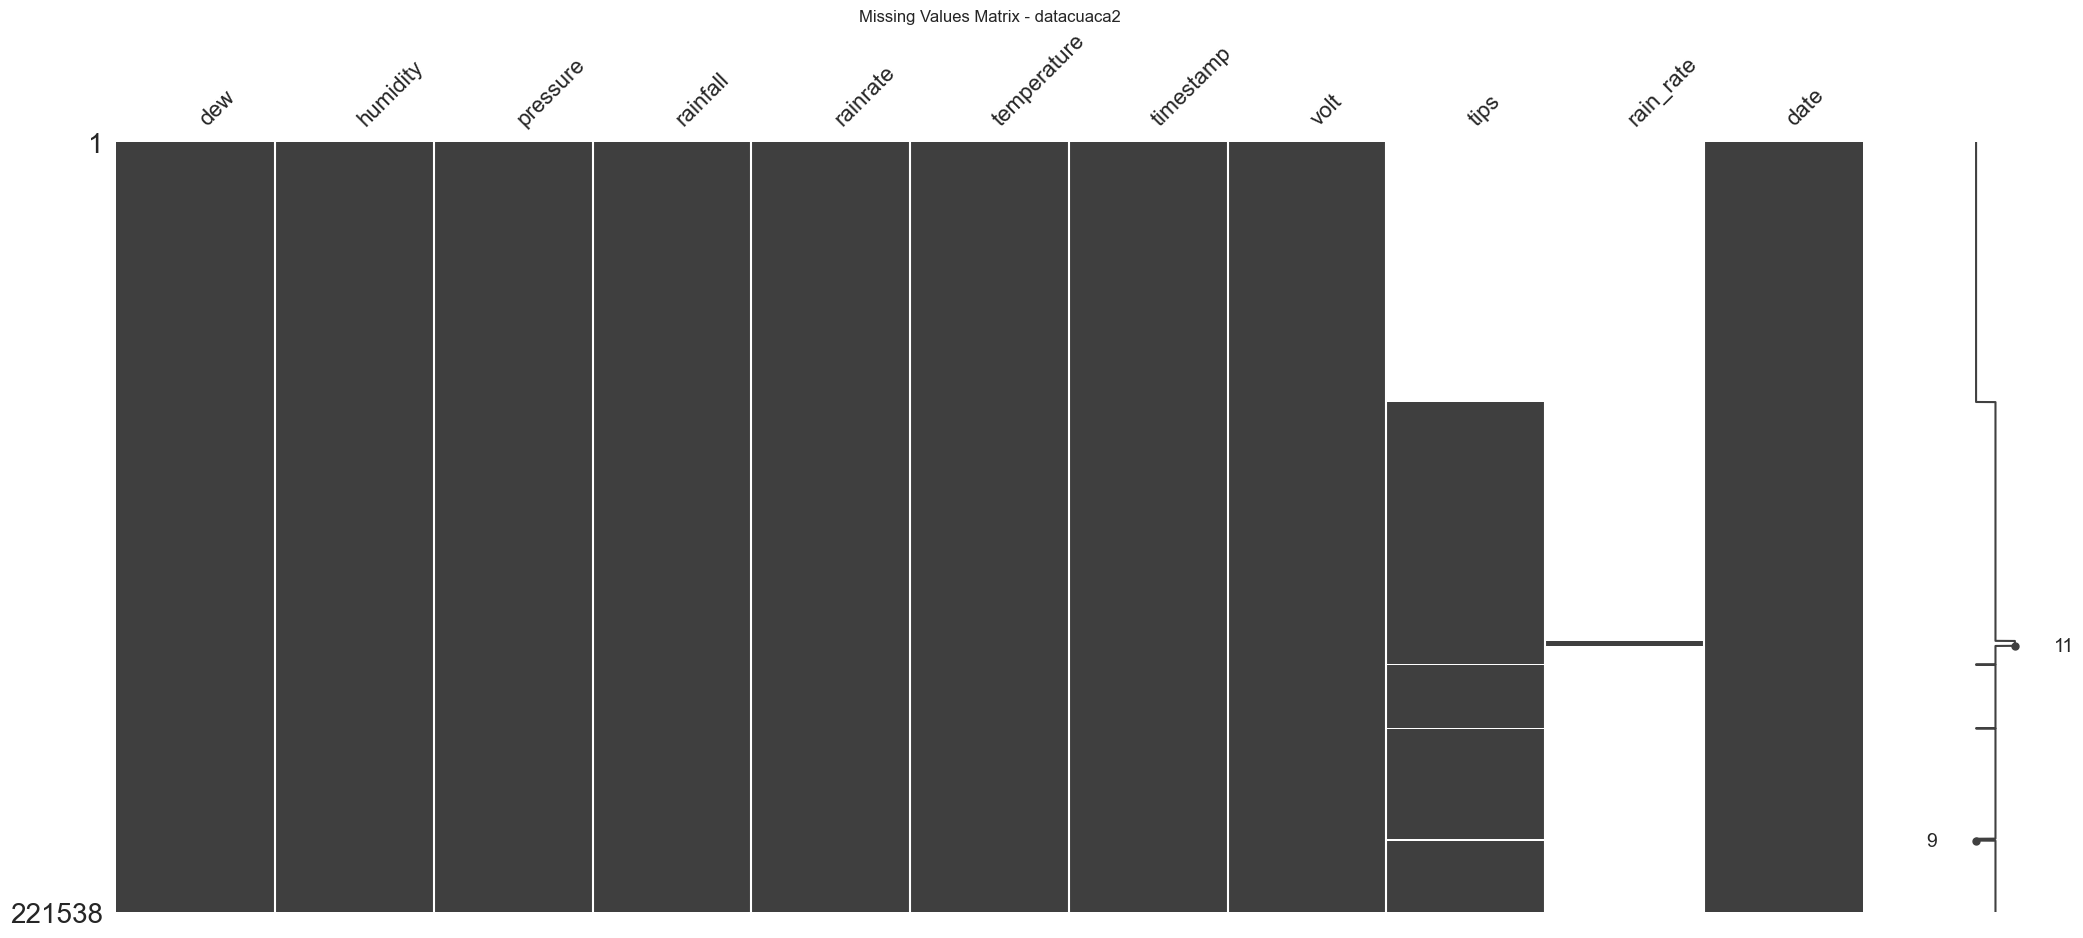

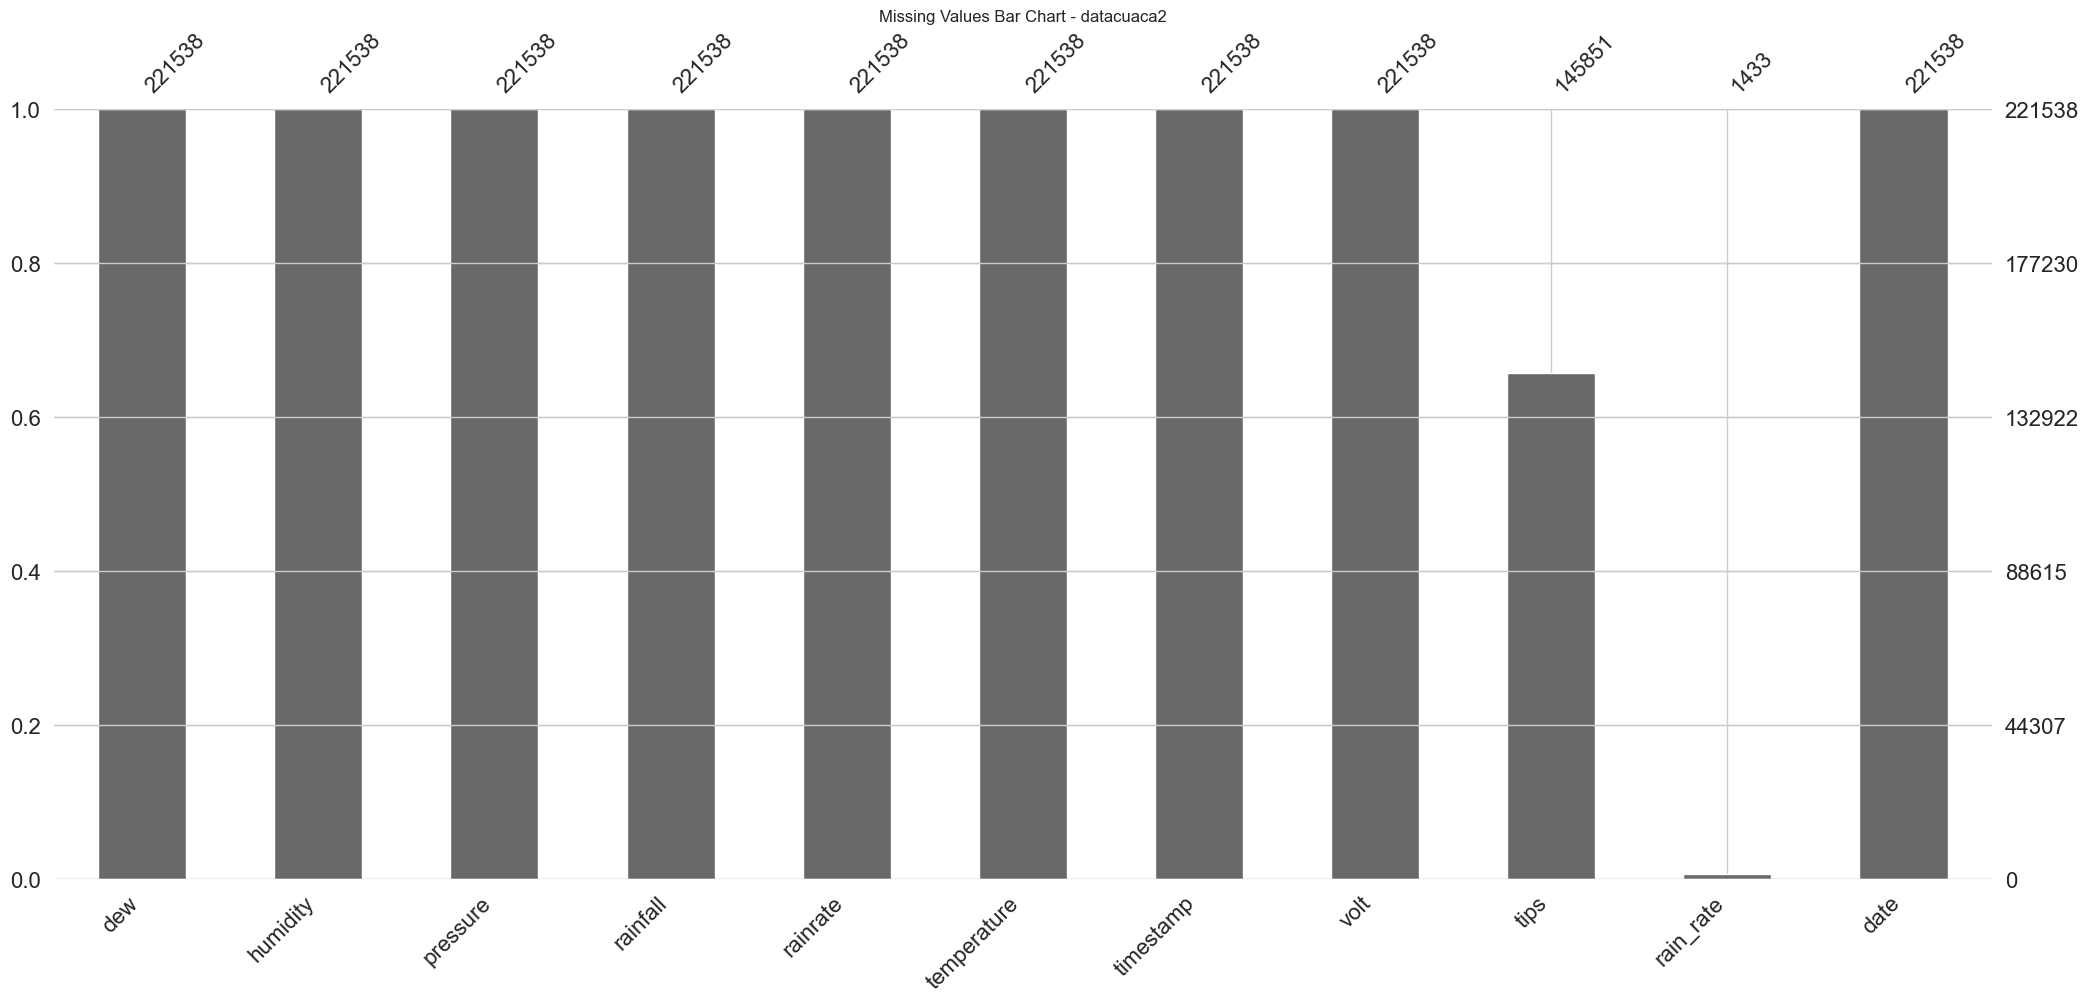

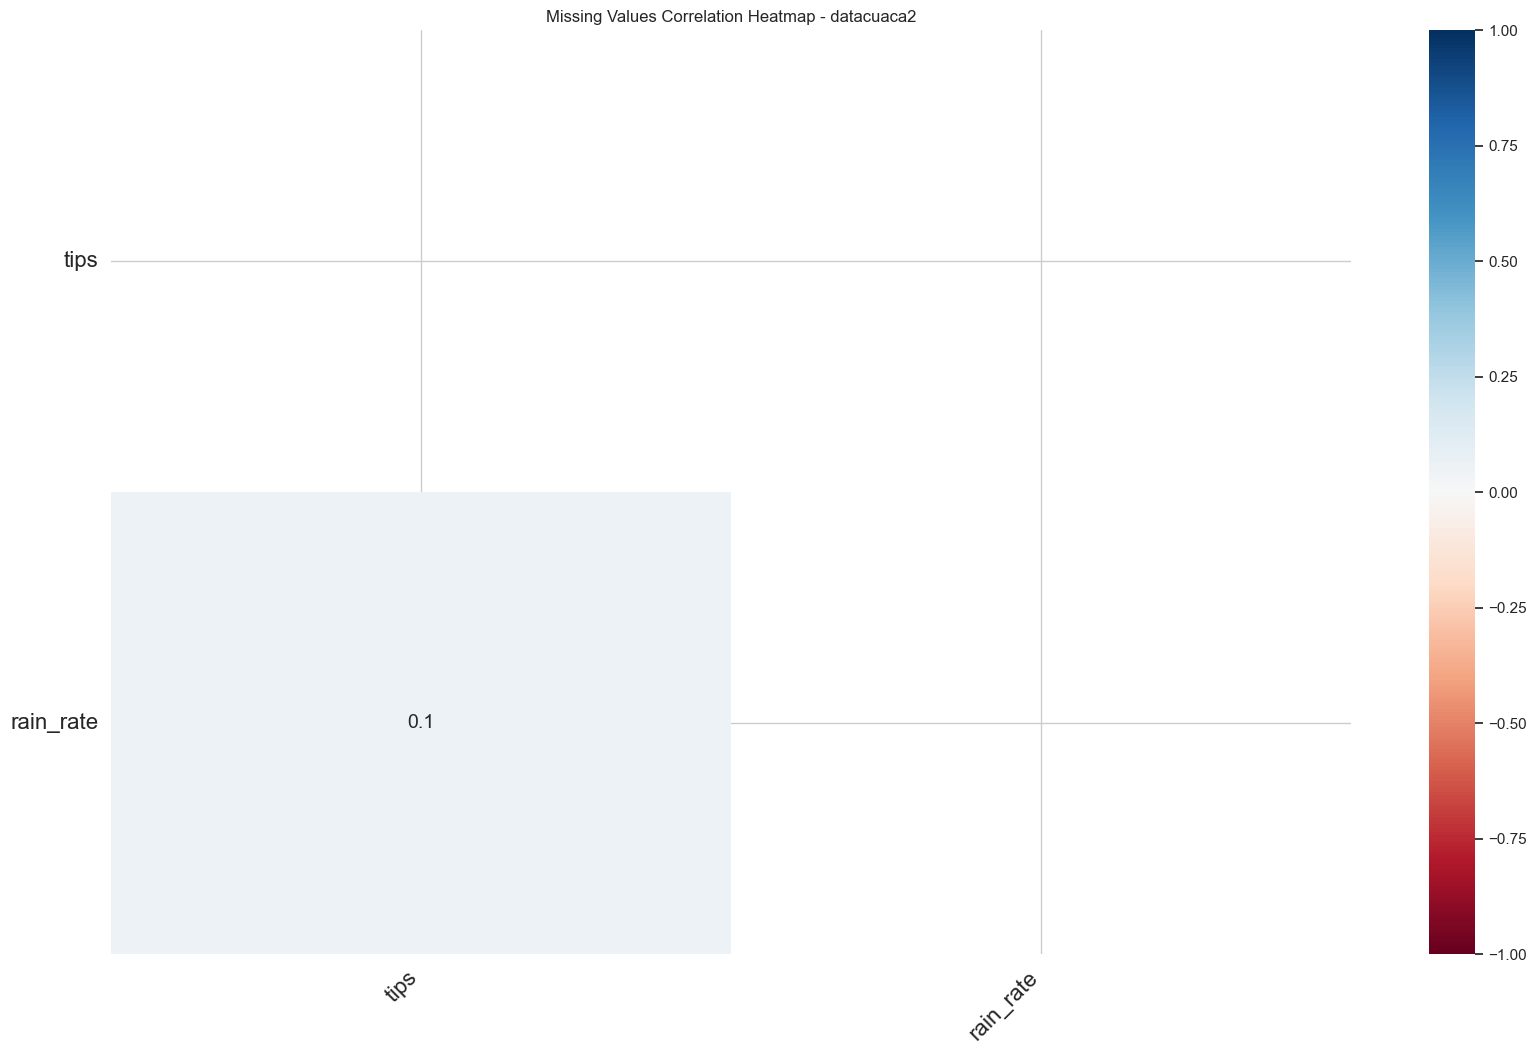

Ringkasan missing values untuk datacuaca:
dew                 0
humidity            0
pressure            0
temperature         0
timestamp           0
volt                0
rainfall       158329
rainrate       158329
lux            221421
soil_temp      221421
tips           216924
date                0
dtype: int64

Ringkasan missing values untuk datacuaca2:
dew                 0
humidity            0
pressure            0
rainfall            0
rainrate            0
temperature         0
timestamp           0
volt                0
tips            75687
rain_rate      220105
date                0
dtype: int64


In [15]:
# Visualisasi missing values untuk datacuaca
print("Visualisasi missing values untuk datacuaca:")
msno.matrix(datacuaca)
plt.title("Missing Values Matrix - datacuaca")
plt.show()

msno.bar(datacuaca)
plt.title("Missing Values Bar Chart - datacuaca")
plt.show()

msno.heatmap(datacuaca)
plt.title("Missing Values Correlation Heatmap - datacuaca")
plt.show()

# Visualisasi missing values untuk datacuaca2
print("Visualisasi missing values untuk datacuaca2:")
msno.matrix(datacuaca2)
plt.title("Missing Values Matrix - datacuaca2")
plt.show()

msno.bar(datacuaca2)
plt.title("Missing Values Bar Chart - datacuaca2")
plt.show()

msno.heatmap(datacuaca2)
plt.title("Missing Values Correlation Heatmap - datacuaca2")
plt.show()

# Menampilkan ringkasan missing values
print("Ringkasan missing values untuk datacuaca:")
print(datacuaca.isnull().sum())

print("\nRingkasan missing values untuk datacuaca2:")
print(datacuaca2.isnull().sum())

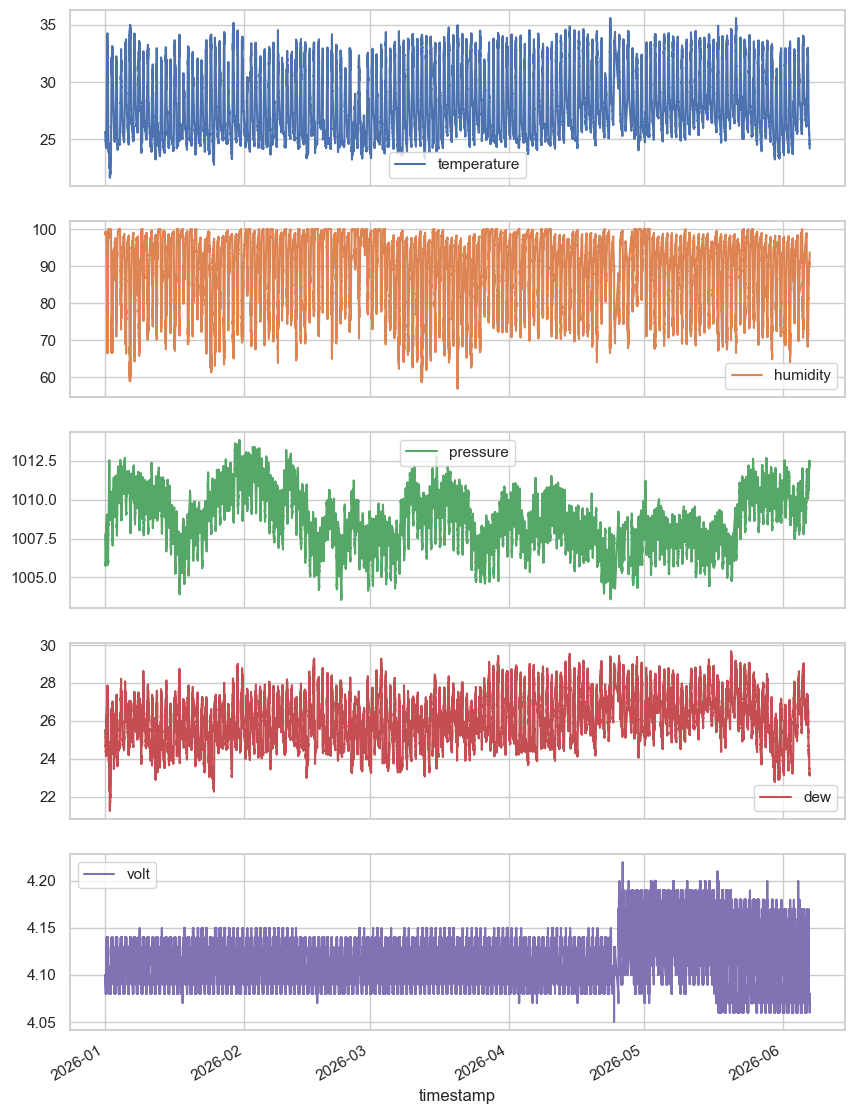

In [16]:
datacuaca.plot(
    y=[
    'temperature', 
    'humidity', 
    'pressure', 
    'dew',
    #'rainrate',
    #'rainfall',
    'volt'
    ],
    x='timestamp',
    subplots=True, figsize=(10, 15))
plt.show()

In [17]:
# Mengubah kolom 'timestamp' menjadi datetime
datacuaca['timestamp'] = pd.to_datetime(datacuaca['timestamp'])

# Mengurutkan data berdasarkan 'timestamp'
datacuaca = datacuaca.sort_values(by='timestamp')

# Menambahkan kolom 'hour', 'minute', 'day', 'month', dan 'year' dari 'timestamp'
datacuaca['hour'] = datacuaca['timestamp'].dt.hour
datacuaca['minute'] = datacuaca['timestamp'].dt.minute
datacuaca['day'] = datacuaca['timestamp'].dt.day
datacuaca['week'] = datacuaca['timestamp'].dt.isocalendar().week
datacuaca['month'] = datacuaca['timestamp'].dt.month
datacuaca['year'] = datacuaca['timestamp'].dt.year

In [18]:
# Mengubah kolom 'timestamp' menjadi datetime
datacuaca2['timestamp'] = pd.to_datetime(datacuaca2['timestamp'])

# Mengurutkan data berdasarkan 'timestamp'
datacuaca2 = datacuaca2.sort_values(by='timestamp')

# Menambahkan kolom 'hour', 'minute', 'day', 'month', dan 'year' dari 'timestamp'
datacuaca2['hour'] = datacuaca2['timestamp'].dt.hour
datacuaca2['minute'] = datacuaca2['timestamp'].dt.minute
datacuaca2['day'] = datacuaca2['timestamp'].dt.day
datacuaca2['week'] = datacuaca2['timestamp'].dt.isocalendar().week
datacuaca2['month'] = datacuaca2['timestamp'].dt.month
datacuaca2['year'] = datacuaca2['timestamp'].dt.year

In [19]:
pilih_tahun = 2026
pilih_bulan = 5

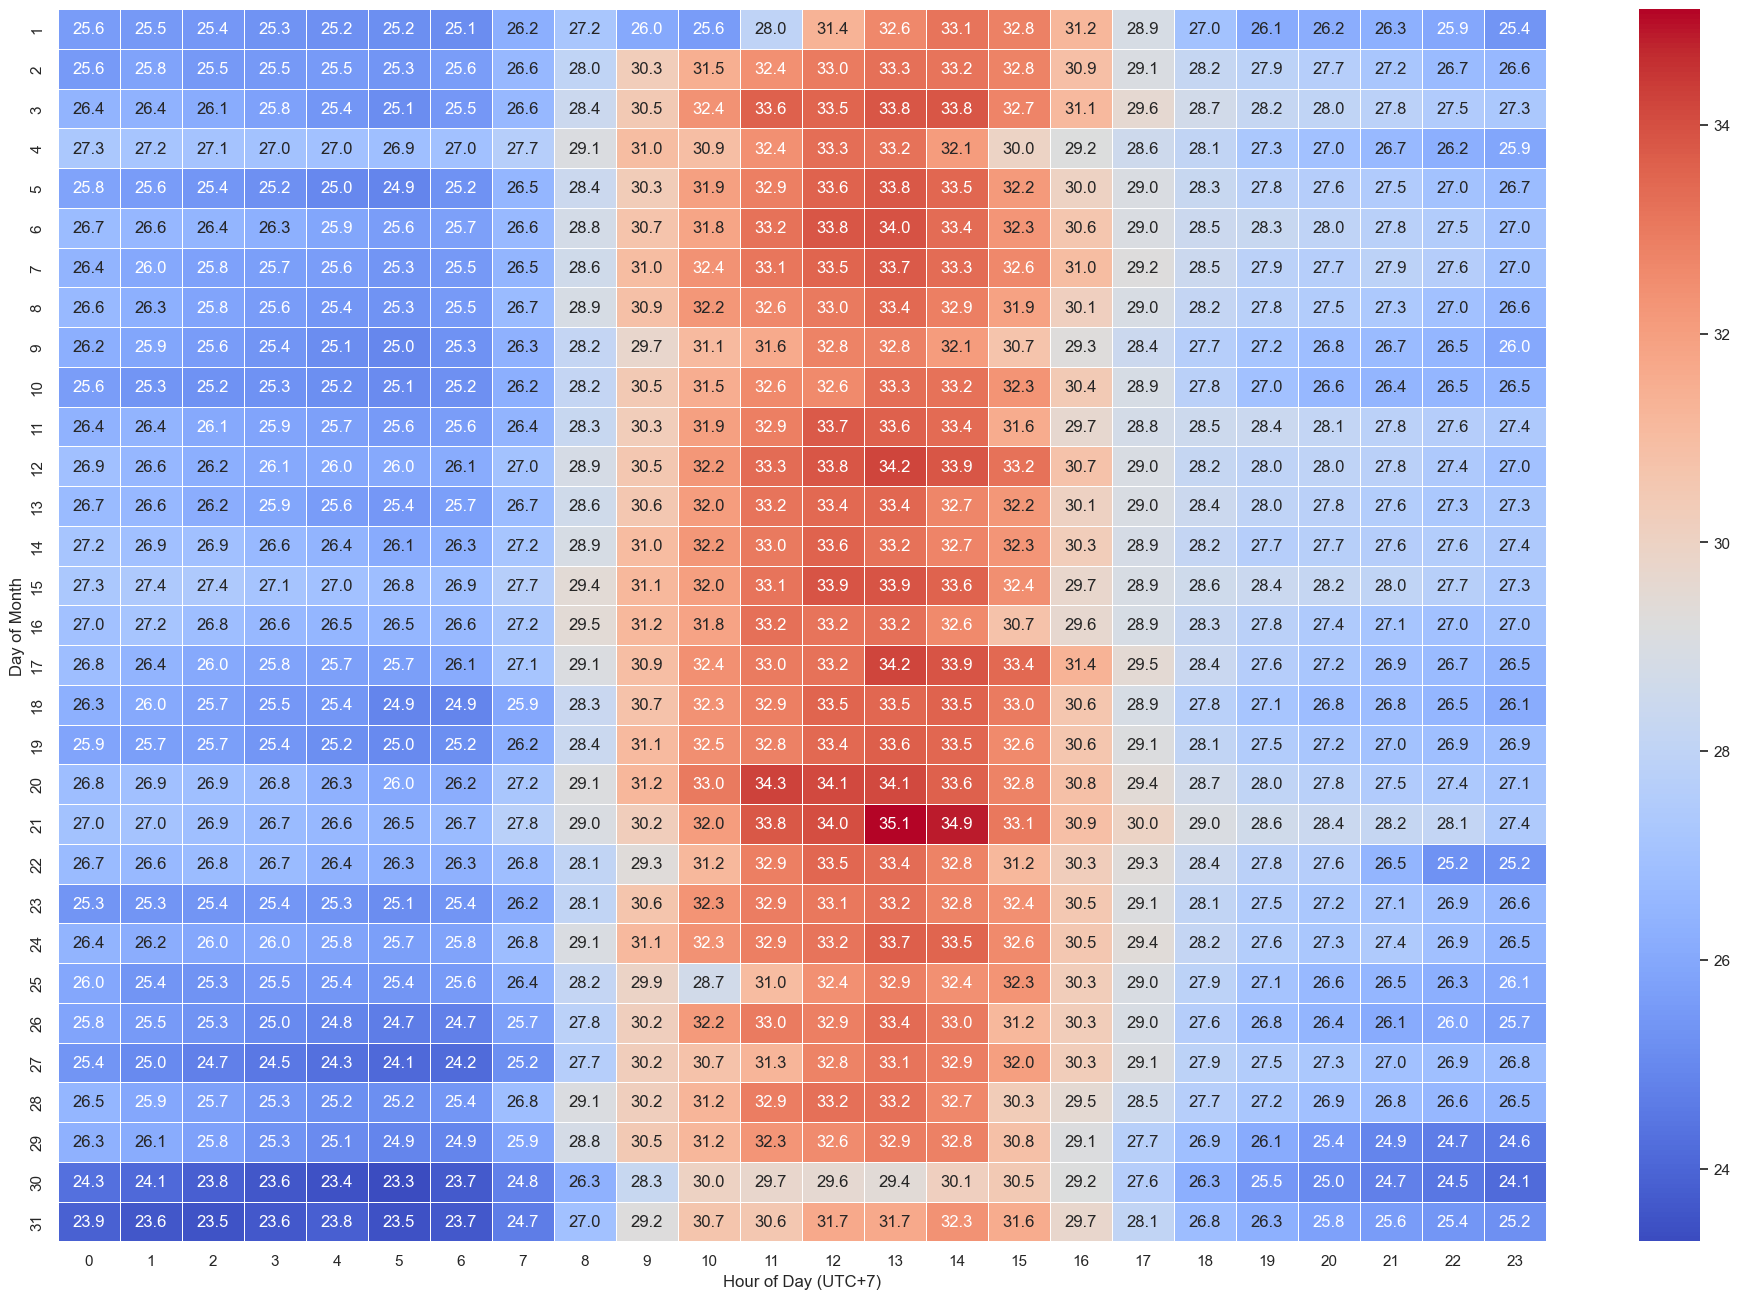

In [20]:
# Mengonversi kolom 'timestamp' menjadi datetime jika belum
datacuaca['timestamp'] = pd.to_datetime(datacuaca['timestamp'])

# Filter data untuk bulan Tertentu
datacuaca_month = datacuaca[(datacuaca['timestamp']
.dt.year == pilih_tahun) & (datacuaca['timestamp']
.dt.month == pilih_bulan)]

# Mengurutkan data berdasarkan 'timestamp'
datacuaca_month = datacuaca_month.sort_values(by='timestamp')

# Mengelompokkan data berdasarkan 'day' dan 'hour', dan menghitung rata-rata suhu
datacuaca_grouped = datacuaca_month.groupby(['day', 'hour']).agg({'temperature': 'mean'}).reset_index()

# Pivot dataframe untuk membuat format yang sesuai dengan heatmap
temperature_pivot = datacuaca_grouped.pivot(index='day', columns='hour', values='temperature')

# Visualisasi heatmap menggunakan seaborn
sns.set_theme()

# Mengatur ukuran grafik
f, ax = plt.subplots(figsize=(24, 16))

# Membuat heatmap dengan anotasi nilai di setiap sel
sns.heatmap(temperature_pivot, annot=True, fmt=".1f", linewidths=.5, ax=ax, cmap="coolwarm")

# Memberi label pada sumbu
ax.set_xlabel('Hour of Day (UTC+7)')
ax.set_ylabel('Day of Month')

# Menampilkan heatmap
plt.savefig("Temp_month" + "_" + str(pilih_tahun) + "_" + str(pilih_bulan) + ".jpg")
plt.show()



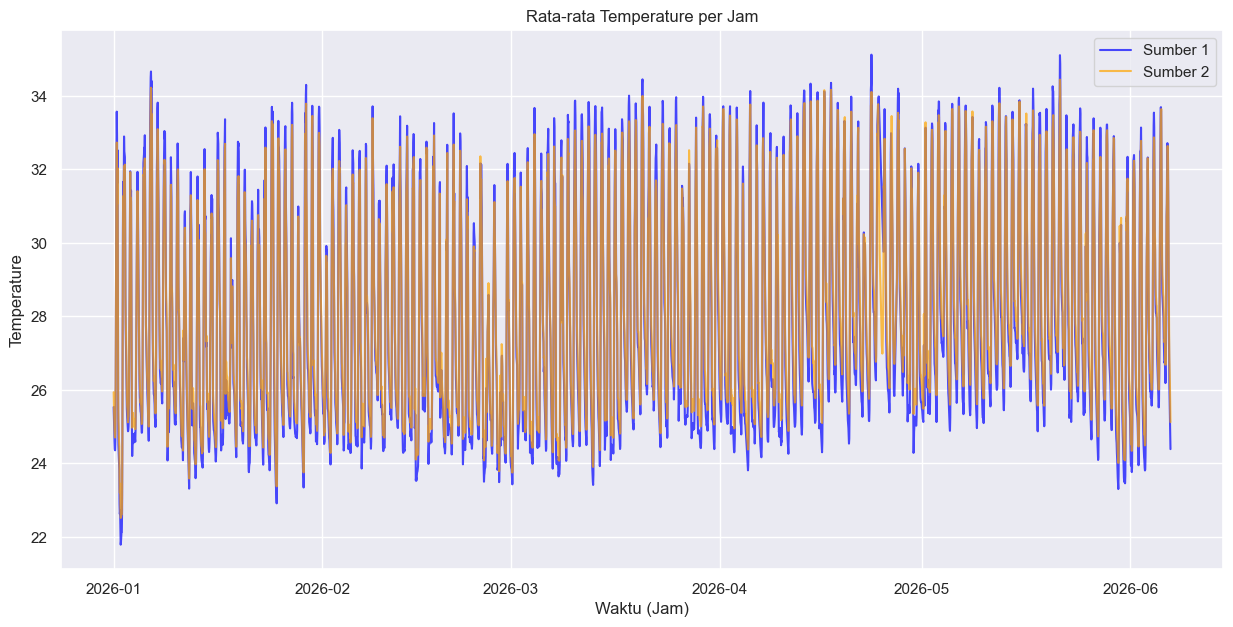

In [21]:
# Variabel pengganti untuk menentukan kolom yang akan digunakan
column_to_plot = 'temperature'  # Ubah ke 'humidity' atau 'pressure' sesuai kebutuhan

# Mengelompokkan data berdasarkan jam dan menghitung rata-rata
datacuaca['hour'] = datacuaca['timestamp'].dt.floor('h')  # Membulatkan ke jam terdekat
datacuaca2['hour'] = datacuaca2['timestamp'].dt.floor('h')

# Menghitung rata-rata per jam untuk kolom yang dipilih
datacuaca_hourly = datacuaca.groupby('hour')[column_to_plot].mean().reset_index()
datacuaca2_hourly = datacuaca2.groupby('hour')[column_to_plot].mean().reset_index()

# Plot data dari kedua DataFrame
plt.figure(figsize=(15, 7))

# Plot data dari datacuaca
plt.plot(datacuaca_hourly['hour'], datacuaca_hourly[column_to_plot], label='Sumber 1', color='blue', alpha=0.7)

# Plot data dari datacuaca2
plt.plot(datacuaca2_hourly['hour'], datacuaca2_hourly[column_to_plot], label='Sumber 2', color='orange', alpha=0.7)

# Menambahkan label, judul, dan legenda
plt.xlabel('Waktu (Jam)')
plt.ylabel(f'{column_to_plot.capitalize()}')
plt.title(f'Rata-rata {column_to_plot.capitalize()} per Jam')
plt.legend()
plt.grid(True)

# Menampilkan plot
plt.show()

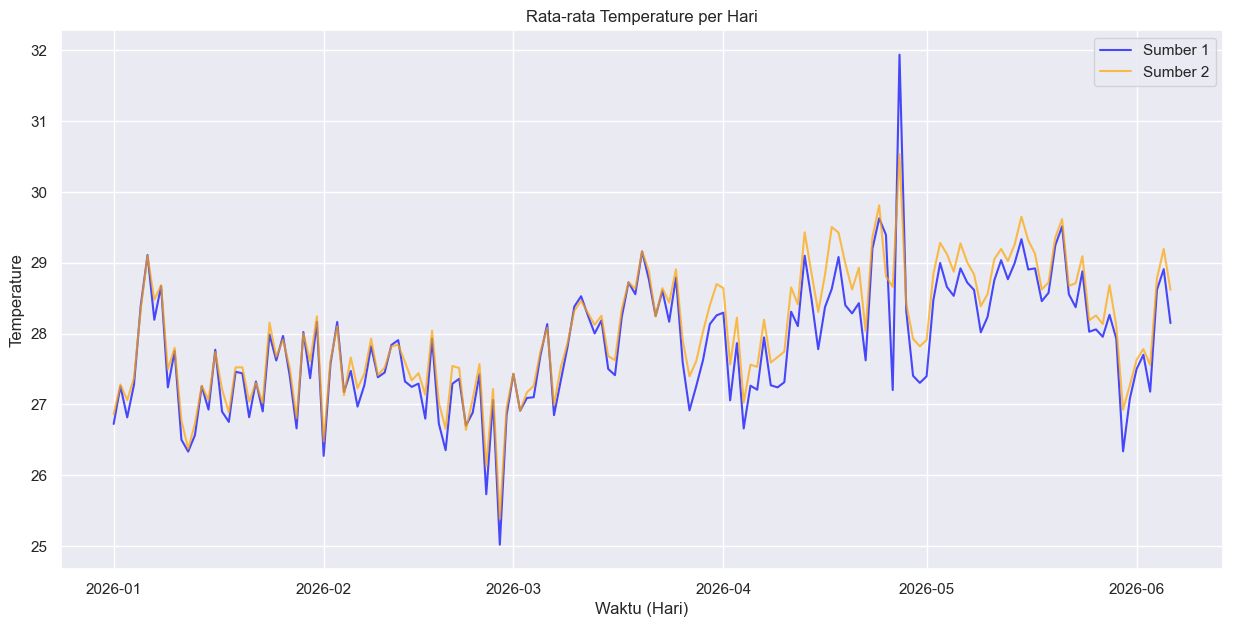

In [22]:
import matplotlib.pyplot as plt

# Variabel pengganti untuk menentukan kolom yang akan digunakan
column_to_plot = 'temperature'  # Ubah ke 'humidity' atau 'pressure' sesuai kebutuhan

# Mengelompokkan data berdasarkan hari dan menghitung rata-rata untuk kolom yang dipilih
datacuaca['day'] = datacuaca['timestamp'].dt.floor('d')  # Membulatkan ke hari terdekat
datacuaca2['day'] = datacuaca2['timestamp'].dt.floor('d')

# Menghitung rata-rata per hari untuk kolom yang dipilih
datacuaca_daily = datacuaca.groupby('day')[column_to_plot].mean().reset_index()
datacuaca2_daily = datacuaca2.groupby('day')[column_to_plot].mean().reset_index()

# Plot data dari kedua DataFrame
plt.figure(figsize=(15, 7))

# Plot data dari datacuaca
plt.plot(datacuaca_daily['day'], datacuaca_daily[column_to_plot], label='Sumber 1', color='blue', alpha=0.7)

# Plot data dari datacuaca2
plt.plot(datacuaca2_daily['day'], datacuaca2_daily[column_to_plot], label='Sumber 2', color='orange', alpha=0.7)

# Menambahkan label, judul, dan legenda
plt.xlabel('Waktu (Hari)')
plt.ylabel(f'{column_to_plot.capitalize()}')
plt.title(f'Rata-rata {column_to_plot.capitalize()} per Hari')
plt.legend()
plt.grid(True)

# Menampilkan plot
plt.show()